## Normalization

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("./Dataset/WineQuality.csv")[['pH','alcohol','quality']]

In [25]:
df.head()

,pH,alcohol,quality
0,3.51,9.4,5.0
1,3.20,9.8,5.0
2,3.26,9.8,5.0
3,3.16,9.8,6.0
4,3.51,9.4,5.0


In [26]:
df.isnull().sum()

pH         0
alcohol    0
quality    0
dtype: int64

### Train_Test_split

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('quality', axis=1) , df['quality'], test_size=0.3 ,random_state=42)
x_train.shape, x_test.shape

((1189, 2), (510, 2))

### MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [29]:
# Numpy Array
x_train_scaled

array([[0.66929134, 0.21538462],
       [0.48818898, 0.26153846],
       [0.46180946, 0.05699867],
       ...,
       [0.60629921, 0.16923077],
       [0.45669291, 0.53846154],
       [0.51181102, 0.78461538]], shape=(1189, 2))

In [30]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=['pH','alcohol'])
x_test_scaled = pd.DataFrame(x_train_scaled, columns=['pH','alcohol'])
x_train_scaled

,pH,alcohol
0,0.669291,0.215385
1,0.488189,0.261538
2,0.461809,0.056999
3,0.661417,0.323077
4,0.127433,0.515522
...,...,...
1184,0.346457,0.307692
1185,0.433071,0.384615
1186,0.606299,0.169231
1187,0.456693,0.538462


In [31]:
x_train.describe().round(1)

,pH,alcohol
count,1189.0,1189.0
mean,3.3,10.4
std,0.2,1.1
min,2.7,8.4
25%,3.2,9.5
50%,3.3,10.2
75%,3.4,11.1
max,4.0,14.9


In [32]:
# Minimum and Maximum Value is [0,1]
x_train_scaled.describe().round(1)

,pH,alcohol
count,1189.0,1189.0
mean,0.5,0.3
std,0.1,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.4,0.3
75%,0.5,0.4
max,1.0,1.0


### Before & After Scaling

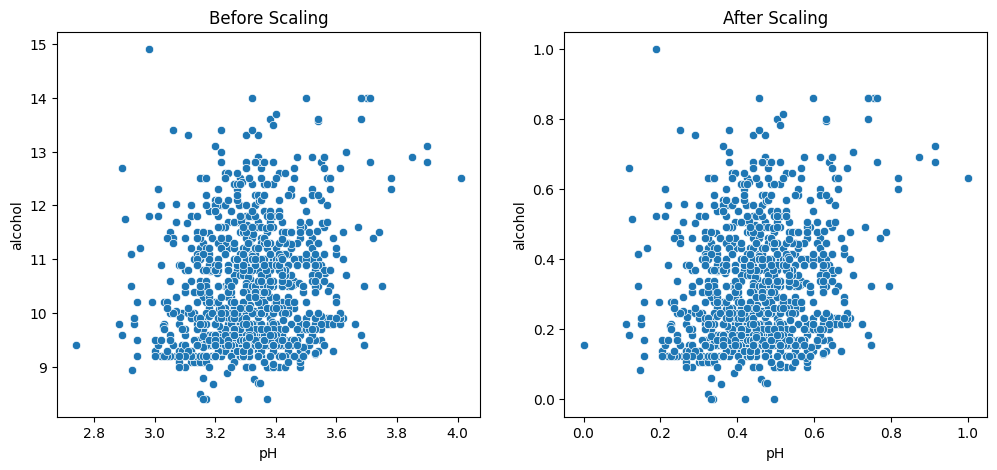

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data = x_train, x = 'pH', y = 'alcohol', ax = axes[0])
axes[0].set_title('Before Scaling')
sns.scatterplot(data = x_train_scaled,  x = 'pH', y = 'alcohol', ax= axes[1])
axes[1].set_title('After Scaling')
plt.show()

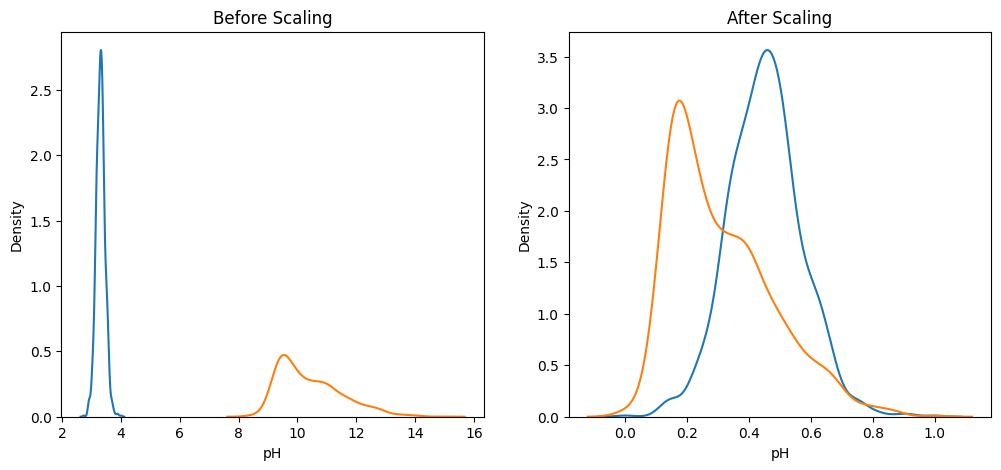

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data = x_train,  x = 'pH', ax = axes[0])
sns.kdeplot(data = x_train,  x = 'alcohol', ax = axes[0])
axes[0].set_title('Before Scaling')
sns.kdeplot(data = x_train_scaled, x = 'pH', ax = axes[1])
sns.kdeplot(data = x_train_scaled, x = 'alcohol', ax = axes[1])
axes[1].set_title('After Scaling')
plt.show()